## ResNet50 Failure Analysis
This notebook uses saved test predictions and manifest metadata to analyze failed predictions.
It selects 3 failure examples from different categories and displays their images.

### Required Files
- `resnet50_pneumonia_cv_test_predictions.csv` `resnet50_pneumothorax_cv_test_predictions.csv` with columns: `y_true`, `y_prob`
- `resnet50_pneumonia_test_manifest.csv` `resnet50_pneumothorax_test_manifest.csv` with columns: `image_path`, `pneumonia`
- Optional: `resnet50_pneumonia_test_threshold.txt` `resnet50_pneumothorax_test_threshold.txt` (fallback threshold is 0.50)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/site-packages/traitlets/config/applicat

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/site-packages/traitlets/config/applicat

AttributeError: _ARRAY_API not found

### Pneumonia

In [2]:
PRED_PATH_MAIN = Path('resnet50_pneumonia_cv_test_predictions.csv')
MANIFEST_PATH = Path('resnet50_pneumonia_test_manifest.csv')
THRESHOLD_PATH = Path('resnet50_pneumonia_test_threshold.txt')

if PRED_PATH_MAIN.exists():
    pred_path = PRED_PATH_MAIN
else:
    raise FileNotFoundError('Missing predictions CSV (resnet50_pneumonia_cv_test_predictions.csv).')

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        'Missing manifest: resnet50_pneumonia_test_manifest.csv. '        'Re-run updated ResNet50_pneumonia_v1.ipynb once to generate it.'
    )

pred_df = pd.read_csv(pred_path)
manifest_df = pd.read_csv(MANIFEST_PATH)

required_pred_cols = {'y_true', 'y_prob'}
required_manifest_cols = {'image_path', 'pneumonia'}
if not required_pred_cols.issubset(pred_df.columns):
    raise ValueError(f'Predictions file must contain: {required_pred_cols}')
if not required_manifest_cols.issubset(manifest_df.columns):
    raise ValueError(f'Manifest file must contain: {required_manifest_cols}')

n = min(len(pred_df), len(manifest_df))
if n == 0:
    raise ValueError('No rows available after loading predictions + manifest.')
if len(pred_df) != len(manifest_df):
    print(f'Length mismatch: predictions={len(pred_df)}, manifest={len(manifest_df)}; using first {n} rows.')

if THRESHOLD_PATH.exists():
    threshold = float(THRESHOLD_PATH.read_text(encoding='utf-8').strip())
else:
    threshold = 0.50

df = manifest_df[['image_path', 'pneumonia']].iloc[:n].reset_index(drop=True).copy()
df['y_true'] = pred_df['y_true'].to_numpy()[:n].astype(int)
df['y_prob'] = pred_df['y_prob'].to_numpy()[:n]
df['y_pred'] = (df['y_prob'] >= threshold).astype(int)
df['is_error'] = (df['y_true'] != df['y_pred']).astype(int)
df['margin'] = np.abs(df['y_prob'] - threshold)

print(f'Loaded rows: {len(df):,}')
print(f'Threshold: {threshold:.3f}')
print(f'Failures: {int(df.is_error.sum()):,}')
display(df.head())


Loaded rows: 1,028
Threshold: 0.500
Failures: 319


,image_path,pneumonia,y_true,y_prob,y_pred,is_error,margin
0,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1,1,0.938359,1,0,0.438359
1,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1,1,0.624289,1,0,0.124289
2,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,0,0.724842,1,1,0.224842
3,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1,1,0.584693,1,0,0.084693
4,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1,1,0.756373,1,0,0.256373


In [3]:
# Define failure categories and pick one example from each category when possible.
errors = df[df['is_error'] == 1].copy()

if errors.empty:
    raise ValueError('No failed predictions found at current threshold.')

# Category 1: High-confidence False Positive (predict 1, true 0, highest probabilities)
fp = errors[(errors['y_true'] == 0) & (errors['y_pred'] == 1)].sort_values('y_prob', ascending=False)

# Category 2: High-confidence False Negative (predict 0, true 1, lowest probabilities)
fn = errors[(errors['y_true'] == 1) & (errors['y_pred'] == 0)].sort_values('y_prob', ascending=True)

# Category 3: Borderline mistake (any error closest to threshold)
borderline = errors.sort_values('margin', ascending=True)

selected_rows = []
used_indices = set()

def add_first_available(candidate_df, category_name):
    for idx, row in candidate_df.iterrows():
        if idx not in used_indices:
            rec = row.to_dict()
            rec['failure_category'] = category_name
            selected_rows.append(rec)
            used_indices.add(idx)
            return True
    return False

add_first_available(fp, 'High-Confidence False Positive')
add_first_available(fn, 'High-Confidence False Negative')
add_first_available(borderline, 'Borderline Misclassification')

# Backfill if we still have <3 examples (e.g., only one error type exists)
if len(selected_rows) < 3:
    for idx, row in errors.sort_values('margin', ascending=False).iterrows():
        if idx in used_indices:
            continue
        rec = row.to_dict()
        rec['failure_category'] = 'Additional Failure Case'
        selected_rows.append(rec)
        used_indices.add(idx)
        if len(selected_rows) == 3:
            break

failure_examples_df = pd.DataFrame(selected_rows).reset_index(drop=True)

print('Selected failure examples:')
print(failure_examples_df[['failure_category', 'image_path', 'y_true', 'y_prob', 'y_pred', 'margin']])


Selected failure examples:
                 failure_category  \
0  High-Confidence False Positive   
1  High-Confidence False Negative   
2    Borderline Misclassification   

                                          image_path  y_true    y_prob  \
0  /nfs/turbo/si-acastel/mimic-project/data_raw/m...       0  0.968001   
1  /nfs/turbo/si-acastel/mimic-project/data_raw/m...       1  0.096997   
2  /nfs/turbo/si-acastel/mimic-project/data_raw/m...       1  0.499852   

   y_pred    margin  
0       1  0.468001  
1       0  0.403003  
2       0  0.000148  


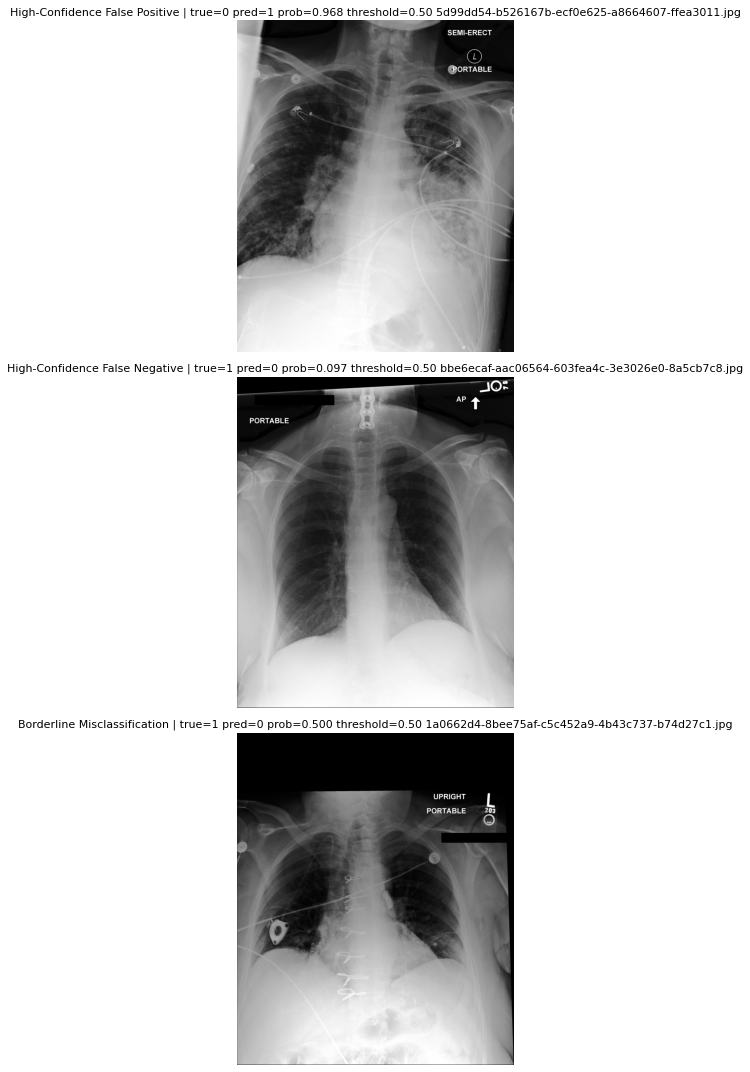

In [6]:
# Visualize selected failure examples.
if failure_examples_df.empty:
    print('No failure examples selected.')
else:
    n = len(failure_examples_df)
    fig, axes = plt.subplots(n, 1, figsize=(10, 5 * n))
    if n == 1:
        axes = [axes]

    for i, (_, row) in enumerate(failure_examples_df.iterrows()):
        ax = axes[i]
        img_path = Path(row['image_path'])

        if img_path.exists():
            img = Image.open(img_path).convert('L')
            ax.imshow(img, cmap='gray')
        else:
            ax.text(0.5, 0.5, f'Missing image file: {img_path}', ha='center', va='center', fontsize=11)
            ax.set_facecolor('#f2f2f2')

        ax.set_title(
            f"{row['failure_category']} | true={int(row['y_true'])} pred={int(row['y_pred'])} " f"prob={row['y_prob']:.3f} threshold={threshold:.2f} {img_path.name}", fontsize=11,
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()


In [7]:
# Save selected examples for reporting.
out_csv = Path('resnet50_pneumonia_failure_examples.csv')
failure_examples_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')
display(failure_examples_df)


Saved: resnet50_pneumonia_failure_examples.csv


,image_path,pneumonia,y_true,y_prob,y_pred,is_error,margin,failure_category
0,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,0,0.968001,1,1,0.468001,High-Confidence False Positive
1,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1,1,0.096997,0,1,0.403003,High-Confidence False Negative
2,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1,1,0.499852,0,1,0.000148,Borderline Misclassification


### Pneumothorax

In [8]:
PRED_PATH_MAIN = Path('resnet50_pneumothorax_cv_test_predictions.csv')
MANIFEST_PATH = Path('resnet50_pneumothorax_test_manifest.csv')
THRESHOLD_PATH = Path('resnet50_pneumothorax_test_threshold.txt')

if PRED_PATH_MAIN.exists():
    pred_path = PRED_PATH_MAIN
else:
    raise FileNotFoundError('Missing predictions CSV (resnet50_pneumonia_cv_test_predictions.csv).')

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        'Missing manifest: resnet50_pneumonia_test_manifest.csv. '        'Re-run updated ResNet50_pneumonia_v1.ipynb once to generate it.'
    )

pred_df = pd.read_csv(pred_path)
manifest_df = pd.read_csv(MANIFEST_PATH)

required_pred_cols = {'y_true', 'y_prob'}
required_manifest_cols = {'image_path', 'pneumothorax'}
if not required_pred_cols.issubset(pred_df.columns):
    raise ValueError(f'Predictions file must contain: {required_pred_cols}')
if not required_manifest_cols.issubset(manifest_df.columns):
    raise ValueError(f'Manifest file must contain: {required_manifest_cols}')

n = min(len(pred_df), len(manifest_df))
if n == 0:
    raise ValueError('No rows available after loading predictions + manifest.')
if len(pred_df) != len(manifest_df):
    print(f'Length mismatch: predictions={len(pred_df)}, manifest={len(manifest_df)}; using first {n} rows.')

if THRESHOLD_PATH.exists():
    threshold = float(THRESHOLD_PATH.read_text(encoding='utf-8').strip())
else:
    threshold = 0.50

df = manifest_df[['image_path', 'pneumothorax']].iloc[:n].reset_index(drop=True).copy()
df['y_true'] = pred_df['y_true'].to_numpy()[:n].astype(int)
df['y_prob'] = pred_df['y_prob'].to_numpy()[:n]
df['y_pred'] = (df['y_prob'] >= threshold).astype(int)
df['is_error'] = (df['y_true'] != df['y_pred']).astype(int)
df['margin'] = np.abs(df['y_prob'] - threshold)

print(f'Loaded rows: {len(df):,}')
print(f'Threshold: {threshold:.3f}')
print(f'Failures: {int(df.is_error.sum()):,}')
display(df.head())


Loaded rows: 1,134
Threshold: 0.625
Failures: 199


,image_path,pneumothorax,y_true,y_prob,y_pred,is_error,margin
0,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,0,0.154789,0,0,0.470211
1,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,0,0.276797,0,0,0.348203
2,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,0,0.208555,0,0,0.416445
3,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,0,0.671858,1,1,0.046858
4,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,0,0.179872,0,0,0.445128


In [9]:
# Define failure categories and pick one example from each category when possible.
errors = df[df['is_error'] == 1].copy()

if errors.empty:
    raise ValueError('No failed predictions found at current threshold.')

# Category 1: High-confidence False Positive (predict 1, true 0, highest probabilities)
fp = errors[(errors['y_true'] == 0) & (errors['y_pred'] == 1)].sort_values('y_prob', ascending=False)

# Category 2: High-confidence False Negative (predict 0, true 1, lowest probabilities)
fn = errors[(errors['y_true'] == 1) & (errors['y_pred'] == 0)].sort_values('y_prob', ascending=True)

# Category 3: Borderline mistake (any error closest to threshold)
borderline = errors.sort_values('margin', ascending=True)

selected_rows = []
used_indices = set()

def add_first_available(candidate_df, category_name):
    for idx, row in candidate_df.iterrows():
        if idx not in used_indices:
            rec = row.to_dict()
            rec['failure_category'] = category_name
            selected_rows.append(rec)
            used_indices.add(idx)
            return True
    return False

add_first_available(fp, 'High-Confidence False Positive')
add_first_available(fn, 'High-Confidence False Negative')
add_first_available(borderline, 'Borderline Misclassification')

# Backfill if we still have <3 examples (e.g., only one error type exists)
if len(selected_rows) < 3:
    for idx, row in errors.sort_values('margin', ascending=False).iterrows():
        if idx in used_indices:
            continue
        rec = row.to_dict()
        rec['failure_category'] = 'Additional Failure Case'
        selected_rows.append(rec)
        used_indices.add(idx)
        if len(selected_rows) == 3:
            break

failure_examples_df = pd.DataFrame(selected_rows).reset_index(drop=True)

print('Selected failure examples:')
print(failure_examples_df[['failure_category', 'image_path', 'y_true', 'y_prob', 'y_pred', 'margin']])

Selected failure examples:
                 failure_category  \
0  High-Confidence False Positive   
1  High-Confidence False Negative   
2    Borderline Misclassification   

                                          image_path  y_true    y_prob  \
0  /nfs/turbo/si-acastel/mimic-project/data_raw/m...       0  0.974756   
1  /nfs/turbo/si-acastel/mimic-project/data_raw/m...       1  0.102172   
2  /nfs/turbo/si-acastel/mimic-project/data_raw/m...       1  0.624046   

   y_pred    margin  
0       1  0.349756  
1       0  0.522828  
2       0  0.000954  


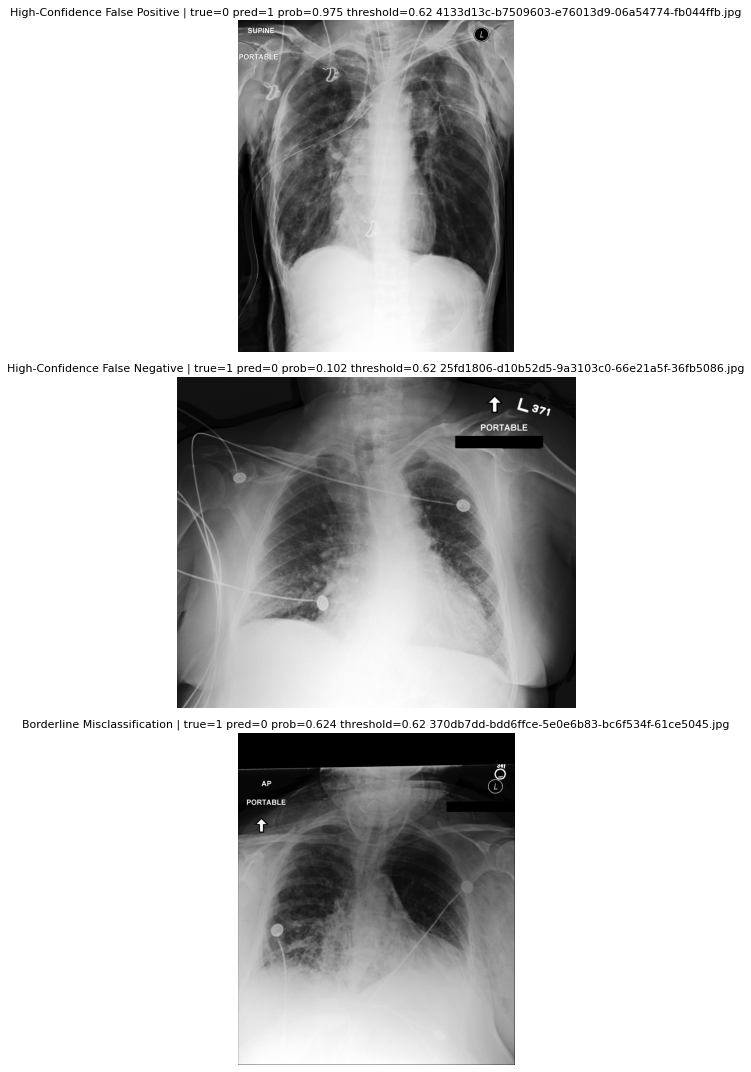

In [10]:
# Visualize selected failure examples.
if failure_examples_df.empty:
    print('No failure examples selected.')
else:
    n = len(failure_examples_df)
    fig, axes = plt.subplots(n, 1, figsize=(10, 5 * n))
    if n == 1:
        axes = [axes]

    for i, (_, row) in enumerate(failure_examples_df.iterrows()):
        ax = axes[i]
        img_path = Path(row['image_path'])

        if img_path.exists():
            img = Image.open(img_path).convert('L')
            ax.imshow(img, cmap='gray')
        else:
            ax.text(0.5, 0.5, f'Missing image file: {img_path}', ha='center', va='center', fontsize=11)
            ax.set_facecolor('#f2f2f2')

        ax.set_title(
            f"{row['failure_category']} | true={int(row['y_true'])} pred={int(row['y_pred'])} " f"prob={row['y_prob']:.3f} threshold={threshold:.2f} {img_path.name}", fontsize=11,
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()


In [11]:
# Save selected examples for reporting.
out_csv = Path('resnet50_pneumothorax_failure_examples.csv')
failure_examples_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')
display(failure_examples_df)

Saved: resnet50_pneumothorax_failure_examples.csv


,image_path,pneumothorax,y_true,y_prob,y_pred,is_error,margin,failure_category
0,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,0,0.974756,1,1,0.349756,High-Confidence False Positive
1,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1,1,0.102172,0,1,0.522828,High-Confidence False Negative
2,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,1,1,0.624046,0,1,0.000954,Borderline Misclassification
